## Importación de librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import sys
sys.path.append('..')
from src.preprocesamiento_data import (
    cargar_datos,
    convertir_fechas,
    eliminar_irrecuperables,
    recuperar_precio_unitario,
    recuperar_items,
    eliminar_nulos_descuento,
    pipeline_clasificacion,
    pipeline_regresion)

# Semilla para reproducibilidad
SEED = 42

##Carga del Dataset


In [4]:
raw_df = pd.read_csv('retail_store_sales.csv')
# respaldo y copia del dataset original
df = raw_df.copy()
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [5]:
print(f"filas x columnas: {df.shape}")
df.dtypes

filas x columnas: (12575, 11)


,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


##Exploracion del dataframe

In [6]:
# comprobamos la cantidad de campos nulos
df.isna().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


Podemos concluir que TODOS los registros tienen un `TRANSACTION_ID`, `CUSTOMER_ID`, `CATEGORY`, `PAYMENT METHOD`,
`LOCATION` y `TRANSACTION DATE`.

In [7]:
# comprobamos si existen transacciones repetidas
id_repetidos = raw_df['Transaction ID'].duplicated().sum()
# comprobamos si en general existen registros repetidos (aunque si no hay transacciones repetidas esto se puede evitar)
datos_Repetidos = raw_df.duplicated().sum()

print(f"La cantidad de transacciones repetidas es: {id_repetidos}")
print(f"La cantidad de datos repetidos es: {datos_Repetidos}")

La cantidad de transacciones repetidas es: 0
La cantidad de datos repetidos es: 0


no existen errores de duplicación y cada transacción es unica

In [ ]:
#buscamos fecha mas alta y antigua en busqueda de valores extremos
print(f"Fecha más antigua: {df['Transaction Date'].min()}")
print(f"Fecha más reciente: {df['Transaction Date'].max()}")

Fecha más antigua: 2022-01-01
Fecha más reciente: 2025-01-18


In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


## Limpieza de Datos

1.-Conversion de fechas

In [ ]:
# Fecha a Timestamp Unix (entero, apto para modelos)
df = convertir_fechas(df)
df[['Transaction Date', 'Timestamp']].head()

,Transaction Date,Timestamp
0,2024-04-08,1712534400
1,2023-07-23,1690070400
2,2022-10-05,1664928000
3,2022-05-07,1651881600
4,2022-10-02,1664668800


2.- Analisis de Nulos en `Price Per Unit`, `Quantity` y `Total Spent`

En los siguientes bloques se buscarán patrones en los que **no se pueden recuperar** los valores de estas columnas.
Si hay menos de 2 campos con datos entre estas 3 columnas, el dato es irrecuperable.

In [ ]:
# En los siguientes 4 bloques se buscarán patrones en los que no se pueden recuperar
# los valores de las columnas 'Price Per Unit', 'Quantity' y 'Total Spent'.
# Esto debido a que por ejemplo, no podemos sacar el total sin la cantidad ni el precio unitario.
# En general si hay menos de 2 campos con datos en estas 3 columnas, el dato es irrecuperable.

# Casos donde 'Price per Unit', 'Quantity' y 'Total Spent' son nulos simultáneamente
filtro_null_1 = df.loc[
    df['Price Per Unit'].isnull() & df['Quantity'].isnull() & df['Total Spent'].isnull(),
    ['Price Per Unit', 'Quantity', 'Total Spent']
]
filtro_null_1.shape

(0, 3)

In [ ]:
# Casos donde 'Cantidad' y 'Total' son Nulos
filtro_null_2 = df.loc[
    df['Quantity'].isnull() & df['Total Spent'].isnull(),
    ['Price Per Unit', 'Quantity', 'Total Spent']
]
filtro_null_2.shape

(604, 3)

In [ ]:
# Casos donde 'Price per Unit' y 'Quantity' son Nulos
filtro_null_3 = df.loc[
    df['Price Per Unit'].isnull() & df['Quantity'].isnull(),
    ['Price Per Unit', 'Quantity', 'Total Spent']
]
filtro_null_3.shape

(0, 3)

In [ ]:
# Casos donde 'Price per Unit' y 'Total' son Nulos
filtro_null_4 = df.loc[
    df['Price Per Unit'].isnull() & df['Total Spent'].isnull(),
    ['Price Per Unit', 'Quantity', 'Total Spent']
]
filtro_null_4.shape

(0, 3)

Podemos observar que de los 4 escenarios posibles donde NO se pueden recuperar estos 3 datos, solo hay 604 escenarios donde no hay cantidad, ni precio unitario. En el resto de casos es recuperable la información. Por ende, solo limpiamos ese escenario.

In [ ]:
# Borramos los escenarios donde no es recuperable (Quantity y Total Spent nulos)
df = eliminar_irrecuperables(df)
# Revisamos los nulls de nuevo
df.isna().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,609
Price Per Unit,609
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


3- Recuperacion de datos  ('Price Per Unit')


Los unicos campos nulos actuales entre las 3 columnas son 609 casos de `Price Per Unit`.
Podemos recuperarlos con la formula: **Price Per Unit = Total Spent / Quantity**

In [ ]:
# Recuperamos Price Per Unit nulo dividiendo Total Spent por Quantity
df = recuperar_precio_unitario(df)
df.isna().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,609
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


4- Restauracion de `Item`



Antes de intentar restaurar los Items, necesitamos explorar informacion que podría tener relevancia:
su categoría y valores únicos.

In [ ]:
# Contamos la cantidad de categorias que existen
cat_size = df['Category'].value_counts()
print(cat_size)

Category
Furniture                             1525
Electric household essentials         1516
Milk Products                         1513
Food                                  1507
Butchers                              1496
Beverages                             1496
Computers and electric accessories    1477
Patisserie                            1441
Name: count, dtype: int64


In [ ]:
# Items unicos por cada categoria
cat_unique = df.groupby('Category')['Item'].nunique()
print(cat_unique)

Category
Beverages                             25
Butchers                              25
Computers and electric accessories    25
Electric household essentials         25
Food                                  25
Furniture                             25
Milk Products                         25
Patisserie                            25
Name: Item, dtype: int64


In [ ]:
# Items unicos en total
items_unique = df.loc[df['Item'].notna(), 'Item'].unique()
print(f"Total de items únicos: {len(items_unique)}")

Total de items únicos: 200


Hay **200 items unicos** y **8 categorias**, por cada categoria hay 25 items unicos que no se repiten.

Ahora verificaremos si cada item tiene un unico valor unitario.

In [ ]:
# Verificamos que cada item tenga un valor unitario unico
# (que un mismo item no tenga 2 valores unitarios distintos)
not_null_items = df.loc[df['Item'].notna()].copy()

# Agrupamos items y guardamos un array de todos los 'Price Per Unit' únicos
item_prices_array = not_null_items.groupby('Item')['Price Per Unit'].unique()

# Evaluamos si existen Items con mas de 1 Price Per Unit
resultado = item_prices_array[item_prices_array.apply(len) > 1]
print(f'Existen {len(resultado)} items que poseen más de 1 Price Per Unit')

Existen 0 items que poseen más de 1 Price Per Unit


Por lo tanto podemos garantizar que cada Item tiene un solo `Price Per Unit`.

Con esta información podemos restaurar algunos items nulos si logramos identificarlos mediante el precio unitario
y la categoría — **siempre y cuando no exista más de un item en una misma categoría con el mismo precio unitario**.

In [ ]:
# Verificamos que no existan items que compartan precio dentro de la misma categoria
item_identify_df = not_null_items.groupby(['Category', 'Item'])['Price Per Unit'].mean().reset_index()
duplicado = item_identify_df.duplicated(subset=['Category', 'Price Per Unit'], keep=False)
casos_duplicados = item_identify_df[duplicado]

print("Items que comparten precio dentro de la misma categoria:")
print(casos_duplicados)

Items que comparten precio dentro de la misma categoria:
Empty DataFrame
Columns: [Category, Item, Price Per Unit]
Index: []


Como podemos observar, cada item dentro de su propia categoria tiene un precio unitario unico.
Por lo que podemos crear un diccionario para identificar items a partir de su precio unitario y categoria.

In [ ]:
# Recuperamos los Items nulos usando el diccionario (Category, Price Per Unit) = Item
df = recuperar_items(df)
df.isna().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


5- LIMPIEZA DE NULOS  EN `Discount Applied`

In [ ]:
# Buscamos los valores nulos en Descuento Aplicado
filtro_null_descuento = df.loc[df['Discount Applied'].isnull(), ['Discount Applied']]
print(f"Filas con descuento nulo: {filtro_null_descuento.shape[0]}")

# Aqui ya no vemos forma de recuperar los nulls en la columna de descuento aplicado
df = eliminar_nulos_descuento(df)
df.isna().sum()

Filas con descuento nulo: 3988


,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


## Visualizaciones y Detección de Patrones

### ¿Qué categorías venden más?

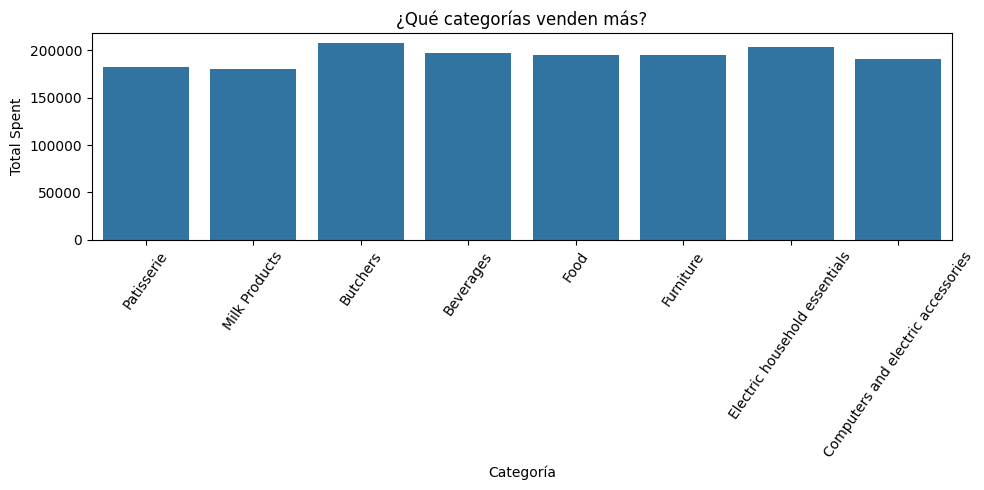

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Category',
    y='Total Spent',
    estimator=sum,
    errorbar=None
)
plt.title('¿Qué categorías venden más?', fontsize=12)
plt.xlabel('Categoría', fontsize=10)
plt.ylabel('Total Spent', fontsize=10)
plt.xticks(rotation=55)
plt.tight_layout()
plt.show()

Las categorías con barras más altas, como "Butchers", son las que generan mayores ingresos para la tienda. Las diferencias entre categorías son pequeñas, lo que sugiere un dataset balanceado.

### Distribución del gasto según método de pago

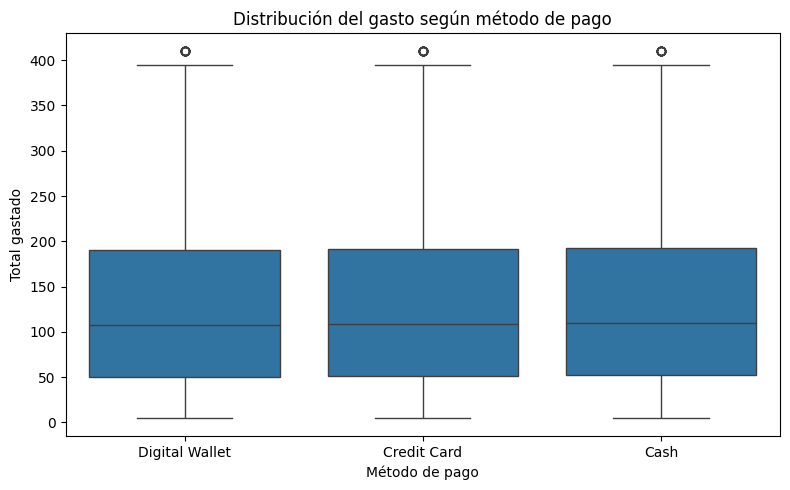

,Total Spent
Payment Method,
Cash,131.052888
Credit Card,129.127069
Digital Wallet,128.718346


In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Payment Method',
    y='Total Spent',
    data=df
)
plt.title('Distribución del gasto según método de pago')
plt.xlabel('Método de pago', fontsize=10)
plt.ylabel('Total gastado', fontsize=10)
plt.tight_layout()
plt.show()

df.groupby('Payment Method')['Total Spent'].mean()

Si una caja tiene una mediana más alta, significa que ese método suele usarse en compras más grandes. Los tres métodos muestran distribuciones muy similares, lo que indica que el método de pago no influye significativamente en el monto gastado.

### Cantidad vs Total Gastado

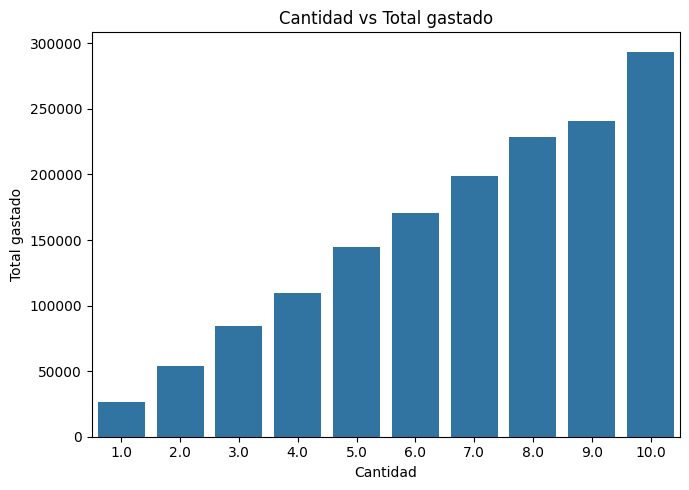

In [10]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x='Quantity',
    y='Total Spent',
    estimator=sum,
    errorbar=None
)
plt.title('Cantidad vs Total gastado', fontsize=12)
plt.xlabel('Cantidad', fontsize=10)
plt.ylabel('Total gastado', fontsize=10)
plt.tight_layout()
plt.show()

Ya que las barras forman una diagonal ascendente, existe una relación positiva: a mayor cantidad comprada, mayor gasto.

### Impacto del descuento en el gasto

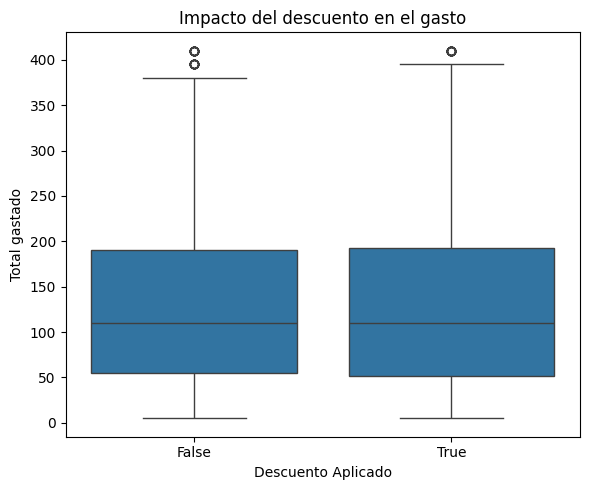

,Total Spent
Discount Applied,
False,129.953330
True,130.491043


In [11]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    x='Discount Applied',
    y='Total Spent',
    data=df
)
plt.title('Impacto del descuento en el gasto')
plt.xlabel('Descuento Aplicado', fontsize=10)
plt.ylabel('Total gastado', fontsize=10)
plt.tight_layout()
plt.show()

df.groupby('Discount Applied')['Total Spent'].mean()

Ya que ambos grupos son similares, el descuento no estaría generando gran impacto.

### Promedio gastado según ubicación

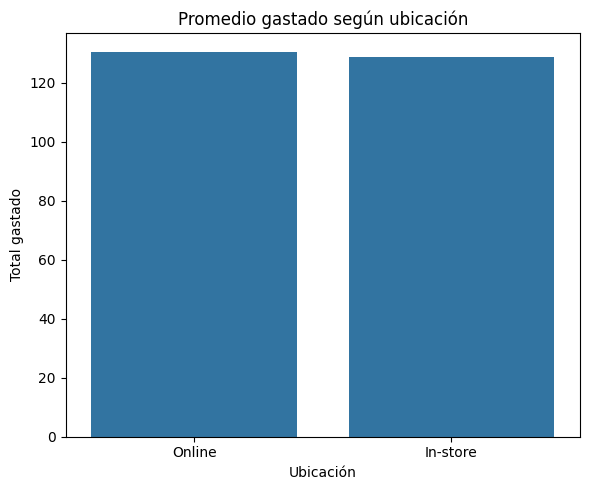

,Total Spent
Location,
In-store,128.861596
Online,130.422050


In [12]:
plt.figure(figsize=(6, 5))
sns.barplot(
    x='Location',
    y='Total Spent',
    data=df,
    estimator='mean',
    errorbar=None
)
plt.title('Promedio gastado según ubicación')
plt.xlabel('Ubicación', fontsize=10)
plt.ylabel('Total gastado', fontsize=10)
plt.tight_layout()
plt.show()

df.groupby('Location')['Total Spent'].mean()

Las ventas online presentan un promedio del total gastado más alto que las realizadas en tienda física, aunque la diferencia es mínima.

### Categoría vs Método de Pago

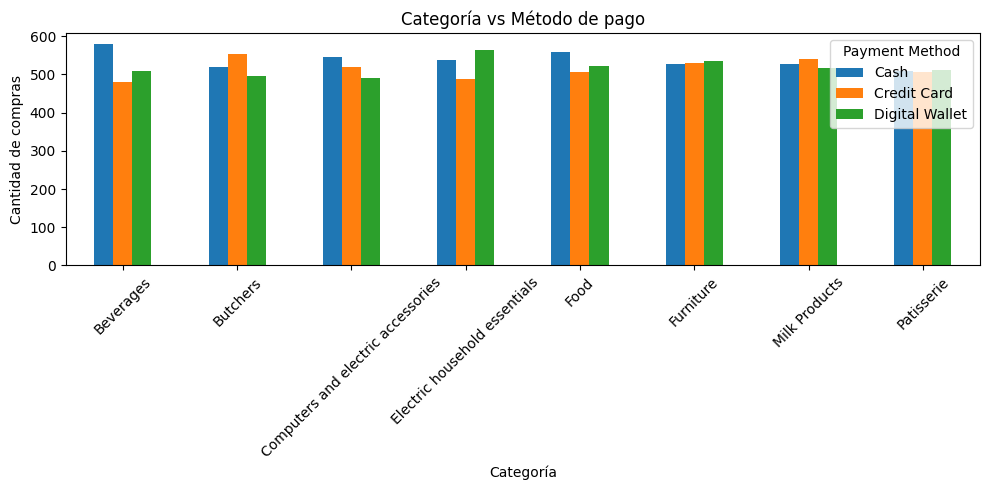

In [13]:
categ_metodo = pd.crosstab(df['Category'], df['Payment Method'])
categ_metodo.plot(kind='bar', figsize=(10, 5))
plt.title('Categoría vs Método de pago')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de compras')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Los métodos de pago se distribuyen de manera uniforme entre categorías, lo que refuerza la homogeneidad del dataset.

### Ventas por Año

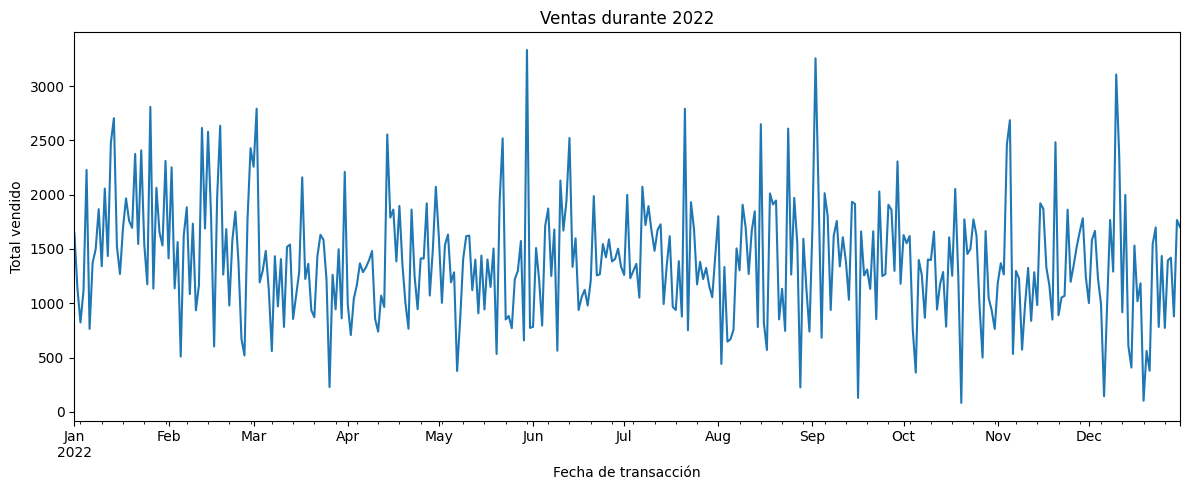

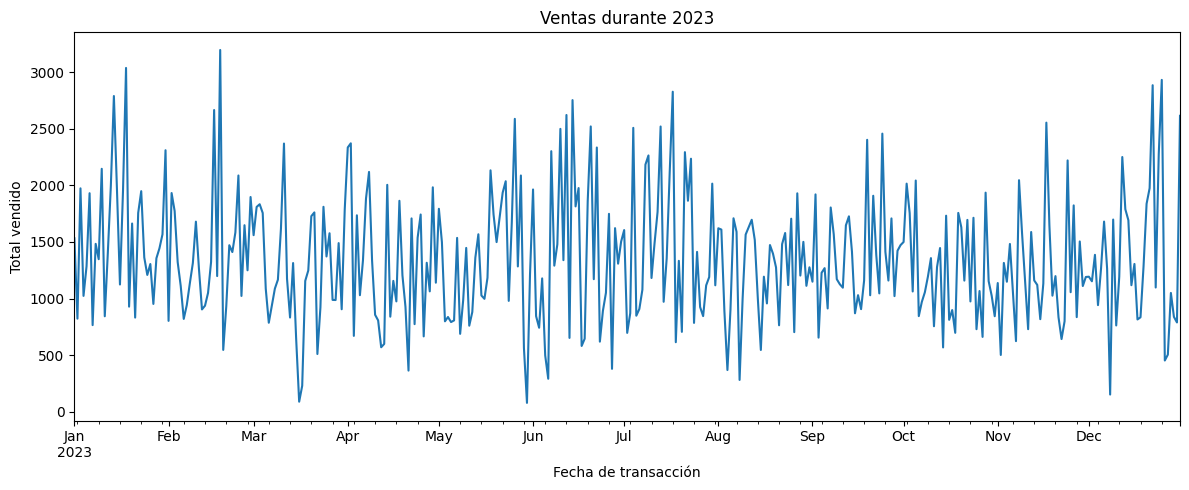

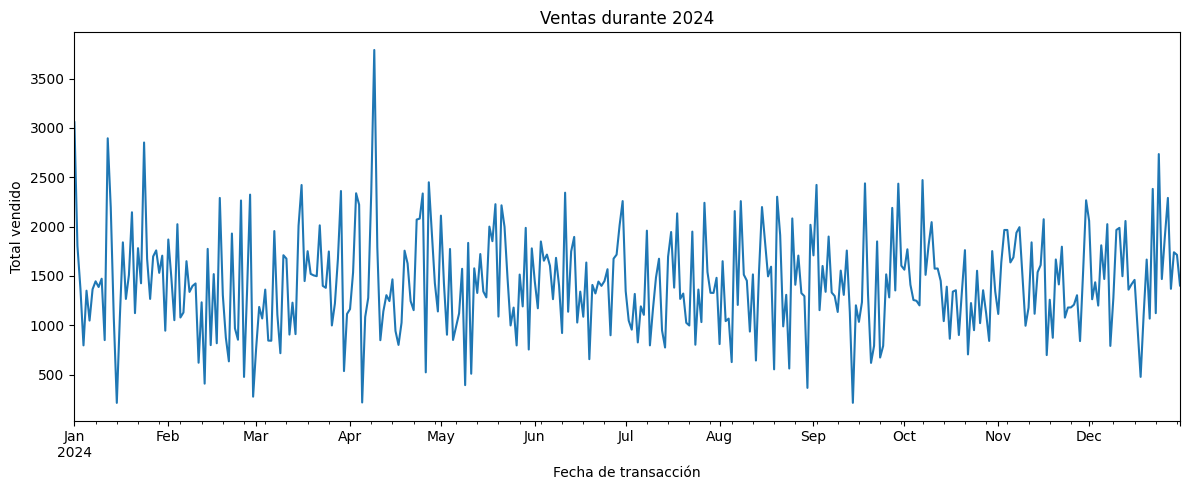

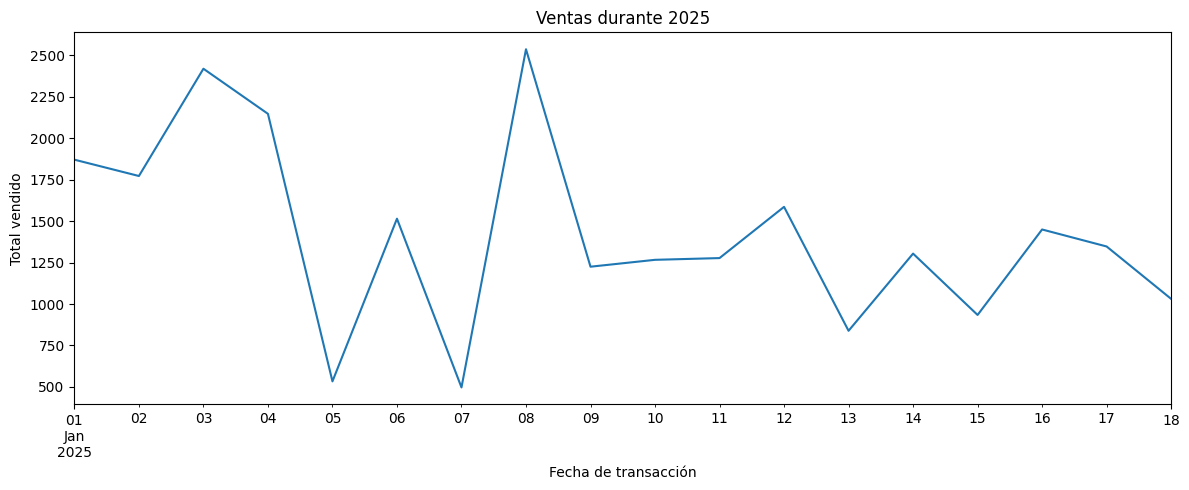

In [14]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Year'] = df['Transaction Date'].dt.year

años = sorted(df['Year'].unique())

for año in años:
    datos_año = df[df['Year'] == año]
    ventas_fecha = datos_año.groupby('Transaction Date')['Total Spent'].sum()

    plt.figure(figsize=(12, 5))
    ventas_fecha.plot()
    plt.title(f'Ventas durante {año}')
    plt.xlabel('Fecha de transacción')
    plt.ylabel('Total vendido')
    plt.tight_layout()
    plt.show()

Solo en diciembre de cada año parece haber comportamientos similares en las ventas, puede deberse a las festividades cercanas como navidad y año nuevo.

### Correlación entre Variables Numéricas

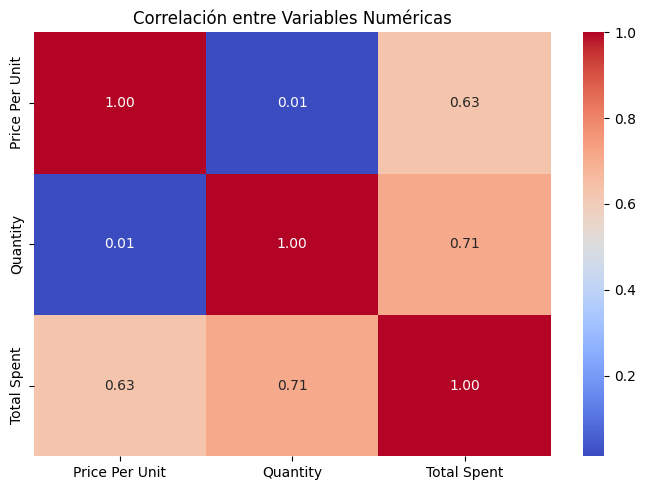

In [16]:
plt.figure(figsize=(7, 5))
corr = df[['Price Per Unit', 'Quantity', 'Total Spent']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre Variables Numéricas')
plt.tight_layout()
plt.show()

`Quantity` tiene la correlación más alta con `Total Spent` (0.71) y `Price Per Unit`
tiene una correlación de 0.63. Dado que `Total Spent` depende directamente de ambas
variables, se deberá tener cuidado al momento de definir los features del modelo
de regresión para evitar redundancia en los datos.